# One-Stage vs Two-Stage (Severstal) - Small-Run First

This notebook builds a **small pilot run** with a unified test set:
- normal
- known defects
- unknown defects (held-out class)

It compares:
- one-stage integrated (PatchCore + Mahalanobis + confidence)
- two-stage cascade (PatchCore gate + confidence/classifier)

In [1]:
# Cell 1: Repo setup + pull latest
import os, sys, subprocess
from pathlib import Path

REPO = Path('/content/FYP-code')
if not REPO.exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/spinelessknave8/FYP_code.git', str(REPO)])
os.chdir(REPO)
subprocess.check_call(['git', 'fetch', 'origin'])
subprocess.check_call(['git', 'reset', '--hard', 'origin/main'])

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
if str(REPO / 'severstral-osr' / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'severstral-osr' / 'src'))

print('cwd:', Path.cwd())

cwd: /content/FYP-code


In [2]:
# Cell 2: Mount drive + write pilot config
import yaml
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

sev = Path('/content/drive/MyDrive/datasets/severstal')
assert sev.exists(), sev

cfg = yaml.safe_load(Path('severstral-osr/configs/default.yaml').read_text())
cfg['device'] = 'cuda'
cfg['severstal']['data_root'] = str(sev)
cfg['output_dir'] = '/content/drive/MyDrive/fyp_outputs/severstral_compare_small'
cfg['resnet']['epochs'] = 6  # pilot speed
cfg['batch_size'] = 32
cfg['num_workers'] = 2
Path('severstral-osr/configs/compare_small.colab.yaml').write_text(yaml.safe_dump(cfg, sort_keys=False))
print('wrote severstral-osr/configs/compare_small.colab.yaml')

Mounted at /content/drive
wrote severstral-osr/configs/compare_small.colab.yaml


In [3]:
# Cell 3: Build small split (normal/known/unknown)
import csv, random, json
from pathlib import Path
from collections import defaultdict

SEED = 42
random.seed(SEED)

UNKNOWN_CLASS = 'Class_4'   # held-out unknown defect class
KNOWN_CLASSES = ['Class_1','Class_2','Class_3']

# per-class caps for pilot
NORM_TRAIN, NORM_VAL, NORM_TEST = 300, 120, 240
DEF_TRAIN_PER_CLASS = 220
DEF_VAL_PER_CLASS = 80
DEF_TEST_PER_CLASS = 120
UNK_TEST_CAP = 260

cfg_path = Path('severstral-osr/configs/compare_small.colab.yaml')
cfg = yaml.safe_load(cfg_path.read_text())
root = Path(cfg['severstal']['data_root'])
csv_path = root / cfg['severstal'].get('train_csv','train.csv')
img_dir = root / cfg['severstal'].get('images_dir','train_images')

def is_mask(v):
    s = str(v).strip().lower()
    return s != '' and s != 'nan'

labels = defaultdict(set)
with csv_path.open('r', newline='') as f:
    r = csv.DictReader(f)
    for row in r:
        if is_mask(row.get('EncodedPixels','')):
            labels[row['ImageId'].strip()].add(int(row['ClassId']))

# single-label defect images by class
by_class = defaultdict(list)
for image_id, cls_set in labels.items():
    if len(cls_set) != 1:
        continue
    c = next(iter(cls_set))
    p = img_dir / image_id
    if p.exists():
        by_class[f'Class_{c}'].append(str(p))

all_imgs = [p for p in img_dir.iterdir() if p.is_file()]
normal_paths = [str(p) for p in all_imgs if p.name not in labels]
random.shuffle(normal_paths)

for k in by_class:
    random.shuffle(by_class[k])

norm_train = normal_paths[:NORM_TRAIN]
norm_val = normal_paths[NORM_TRAIN:NORM_TRAIN+NORM_VAL]
norm_test = normal_paths[NORM_TRAIN+NORM_VAL:NORM_TRAIN+NORM_VAL+NORM_TEST]

known_train, known_val, known_test = [], [], []
for k in KNOWN_CLASSES:
    items = by_class[k]
    known_train += [(p,k) for p in items[:DEF_TRAIN_PER_CLASS]]
    known_val += [(p,k) for p in items[DEF_TRAIN_PER_CLASS:DEF_TRAIN_PER_CLASS+DEF_VAL_PER_CLASS]]
    known_test += [(p,k) for p in items[DEF_TRAIN_PER_CLASS+DEF_VAL_PER_CLASS:DEF_TRAIN_PER_CLASS+DEF_VAL_PER_CLASS+DEF_TEST_PER_CLASS]]

unknown_test = [(p, UNKNOWN_CLASS) for p in by_class[UNKNOWN_CLASS][:UNK_TEST_CAP]]

manifest = {
    'unknown_class': UNKNOWN_CLASS,
    'known_classes': KNOWN_CLASSES,
    'normal_train': norm_train,
    'normal_val': norm_val,
    'normal_test': norm_test,
    'known_train': known_train,
    'known_val': known_val,
    'known_test': known_test,
    'unknown_test': unknown_test,
}

out_manifest = Path(cfg['output_dir']) / 'pilot_manifest.json'
out_manifest.parent.mkdir(parents=True, exist_ok=True)
out_manifest.write_text(json.dumps(manifest))

print('manifest:', out_manifest)
print('normal train/val/test:', len(norm_train), len(norm_val), len(norm_test))
print('known train/val/test:', len(known_train), len(known_val), len(known_test))
print('unknown test:', len(unknown_test))

manifest: /content/drive/MyDrive/fyp_outputs/severstral_compare_small/pilot_manifest.json
normal train/val/test: 300 120 240
known train/val/test: 635 160 240
unknown test: 260


In [4]:
# Cell 4: Train pilot classifier on known defect classes only (with timing)
import time
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

from src.models.resnet50 import build_resnet50
from src.models.embedding import EmbeddingExtractor
from src.utils.device import get_device

cfg = yaml.safe_load(Path('severstral-osr/configs/compare_small.colab.yaml').read_text())
manifest = json.loads((Path(cfg['output_dir']) / 'pilot_manifest.json').read_text())

KNOWN_CLASSES = manifest['known_classes']
class_to_idx = {c:i for i,c in enumerate(KNOWN_CLASSES)}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

tf = transforms.Compose([
    transforms.Resize((cfg['image_size'], cfg['image_size'])),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class DS(Dataset):
    def __init__(self, items, class_to_idx=None):
        self.items = items
        self.class_to_idx = class_to_idx
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        x, y = self.items[i]
        img = tf(Image.open(x).convert('RGB'))
        if self.class_to_idx is None:
            return img, y
        return img, self.class_to_idx[y]

train_ds = DS(manifest['known_train'], class_to_idx)
val_ds = DS(manifest['known_val'], class_to_idx)

train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True, num_workers=cfg['num_workers'])
val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False, num_workers=cfg['num_workers'])

device = get_device(cfg['device'])
model = build_resnet50(num_classes=len(KNOWN_CLASSES), pretrained=True).to(device)
opt = torch.optim.Adam(model.parameters(), lr=float(cfg['resnet']['lr']), weight_decay=float(cfg['resnet']['weight_decay']))
criterion = nn.CrossEntropyLoss()

train_t0 = time.perf_counter()
best_val = -1
best_state = None
for ep in range(int(cfg['resnet']['epochs'])):
    model.train(); t_ok=t_n=0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = criterion(logits,y)
        loss.backward(); opt.step()
        t_ok += (logits.argmax(1)==y).sum().item(); t_n += x.size(0)
    tr_acc = t_ok / max(1,t_n)

    model.eval(); v_ok=v_n=0
    with torch.no_grad():
        for x,y in val_loader:
            x,y=x.to(device),y.to(device)
            logits=model(x)
            v_ok += (logits.argmax(1)==y).sum().item(); v_n += x.size(0)
    va = v_ok / max(1,v_n)
    print(f'epoch {ep+1}/{cfg["resnet"]["epochs"]} train_acc={tr_acc:.3f} val_acc={va:.3f}')
    if va > best_val:
        best_val = va
        best_state = model.state_dict()
train_sec = time.perf_counter() - train_t0

model.load_state_dict(best_state)
clf_dir = Path(cfg['output_dir']) / 'pilot_classifier'
clf_dir.mkdir(parents=True, exist_ok=True)
torch.save({'model_state': model.state_dict(), 'class_to_idx': class_to_idx}, clf_dir / 'classifier.pt')
print('saved:', clf_dir / 'classifier.pt', 'best_val=', round(best_val,4), 'train_sec=', round(train_sec,2))

# Persist runtime info
runtime_path = Path(cfg['output_dir']) / 'pilot_runtime.json'
runtime = {}
if runtime_path.exists():
    runtime = json.loads(runtime_path.read_text())
runtime['classifier_train_sec'] = float(train_sec)
runtime['classifier_epochs'] = int(cfg['resnet']['epochs'])
runtime['classifier_train_samples'] = len(train_ds)
runtime['classifier_val_samples'] = len(val_ds)
runtime_path.write_text(json.dumps(runtime, indent=2))
print('runtime file:', runtime_path)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


epoch 1/6 train_acc=0.710 val_acc=0.606
epoch 2/6 train_acc=0.830 val_acc=0.562
epoch 3/6 train_acc=0.872 val_acc=0.662
epoch 4/6 train_acc=0.876 val_acc=0.631
epoch 5/6 train_acc=0.909 val_acc=0.794
epoch 6/6 train_acc=0.921 val_acc=0.856
saved: /content/drive/MyDrive/fyp_outputs/severstral_compare_small/pilot_classifier/classifier.pt best_val= 0.8562 train_sec= 257.85
runtime file: /content/drive/MyDrive/fyp_outputs/severstral_compare_small/pilot_runtime.json


In [5]:
# Cell 5: Ensure PatchCore stage-1 artifacts exist (cached skip, with timing)
import time
from notebook_entrypoints import run_stage1

cfg = yaml.safe_load(Path('severstral-osr/configs/compare_small.colab.yaml').read_text())
runtime_path = Path(cfg['output_dir']) / 'pilot_runtime.json'
runtime = json.loads(runtime_path.read_text()) if runtime_path.exists() else {}

t0 = time.perf_counter()
run_stage1('severstral-osr/configs/compare_small.colab.yaml')
stage1_sec = time.perf_counter() - t0
print('stage1 wall time (this run):', round(stage1_sec,2), 'sec')

runtime['stage1_train_or_load_sec'] = float(stage1_sec)
runtime_path.write_text(json.dumps(runtime, indent=2))
print('runtime file:', runtime_path)


[severstal-osr] stage1 start: severstral-osr/configs/compare_small.colab.yaml
[two-stage] Stage 1 PatchCore setup complete
  normal images total: 5902
  normal train images: 5312
  normal val images: 590
  train patches: 37184
  val patches: 4130
  patch size/stride: 224/224
  elapsed setup: 109.5s
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


[two-stage] Building memory bank...


[two-stage] Memory bank built: 148736 vectors in 248.7s
[two-stage] Saved pre-coreset memory: /content/drive/MyDrive/fyp_outputs/severstral_compare_small/patchcore/memory_precoreset.npy
[two-stage] Applying coreset subsampling...
[two-stage] Coreset done: 14873 vectors in 0.5s
[two-stage] Saved coreset memory: /content/drive/MyDrive/fyp_outputs/severstral_compare_small/patchcore/memory.npy
[two-stage] Scoring validation patches for threshold calibration...
[two-stage] Saved val-score checkpoint at batch 5/130
[two-stage] Saved val-score checkpoint at batch 10/130
[two-stage] Saved val-score checkpoint at batch 15/130
[two-stage] Saved val-score checkpoint at batch 20/130
[two-stage] Saved val-score checkpoint at batch 25/130
[two-stage] Saved val-score checkpoint at batch 30/130
[two-stage] Saved val-score checkpoint at batch 35/130
[two-stage] Saved val-score checkpoint at batch 40/130
[two-stage] Saved val-score checkpoint at batch 45/130
[two-stage] Saved val-score checkpoint at bat

In [7]:
import json, yaml
from pathlib import Path

import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

from src.utils.device import get_device

cfg = yaml.safe_load(Path('severstral-osr/configs/compare_small.colab.yaml').read_text())
manifest = json.loads((Path(cfg['output_dir']) / 'pilot_manifest.json').read_text())
KNOWN_CLASSES = manifest['known_classes']
class_to_idx = {c: i for i, c in enumerate(KNOWN_CLASSES)}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

tf = transforms.Compose([
    transforms.Resize((cfg['image_size'], cfg['image_size'])),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class DS(Dataset):
    def __init__(self, items, class_to_idx=None):
        self.items = items
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        x, y = self.items[i]
        img = tf(Image.open(x).convert('RGB'))
        if self.class_to_idx is None:
            return img, y
        return img, self.class_to_idx[y]

device = get_device(cfg['device'])
print("Fallback ready. device =", device)

Fallback ready. device = cuda


In [8]:
# Cell 6: Inference on all groups (normal/known/unknown) + timing
import time
import numpy as np
from src.patchcore.patchcore_simple import PatchCoreBackbone, infer_anomaly_scores
from src.osr.gaussian_mahalanobis import fit_gaussians, batch_min_mahalanobis
import os, sys, time, json, csv, random, yaml
import numpy as np
import pandas as pd
from pathlib import Path
import os
import sys
import csv
import json
import time
import random
from pathlib import Path

import yaml
import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader

from src.models.resnet50 import build_resnet50
from src.models.embedding import EmbeddingExtractor
from src.patchcore.patchcore_simple import PatchCoreBackbone, infer_anomaly_scores
from src.osr.gaussian_mahalanobis import fit_gaussians, batch_min_mahalanobis

def softmax_np(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

cfg = yaml.safe_load(Path('severstral-osr/configs/compare_small.colab.yaml').read_text())
manifest = json.loads((Path(cfg['output_dir']) / 'pilot_manifest.json').read_text())
ckpt = torch.load(Path(cfg['output_dir']) / 'pilot_classifier' / 'classifier.pt', map_location='cpu')
class_to_idx = ckpt['class_to_idx']
idx_to_class = {v:k for k,v in class_to_idx.items()}

model = build_resnet50(num_classes=len(class_to_idx), pretrained=False)
model.load_state_dict(ckpt['model_state'])
model.to(device); model.eval()
extractor = EmbeddingExtractor(model).to(device)

patch_dir = Path(cfg['output_dir']) / 'patchcore'
memory = np.load(patch_dir / 'memory.npy')
source_tau = float(json.loads((patch_dir / 'threshold.json').read_text())['threshold'])
backbone = PatchCoreBackbone(cfg['patchcore']['backbone']).to(device)

def make_loader(items, with_label=True):
    if with_label:
        ds = DS(items, class_to_idx if isinstance(items[0][1], str) and items[0][1] in class_to_idx else None)
    else:
        ds = DS(items, None)
    return DataLoader(ds, batch_size=cfg['batch_size'], shuffle=False, num_workers=cfg['num_workers'])

timing = {'patch_sec_by_group': {}, 'cls_emb_sec_by_group': {}, 'n_by_group': {}}

def infer_group(items, group_name, labels_known=True):
    loader = make_loader(items, with_label=True)
    timing['n_by_group'][group_name] = len(items)

    t0 = time.perf_counter()
    p_scores = infer_anomaly_scores(loader, device, backbone, memory)
    timing['patch_sec_by_group'][group_name] = float(time.perf_counter() - t0)

    t1 = time.perf_counter()
    all_logits, all_emb, all_y = [], [], []
    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            logits = model(x)
            emb = extractor(x)
            all_logits.append(logits.cpu().numpy())
            all_emb.append(emb.cpu().numpy())
            if torch.is_tensor(y):
                all_y.append(y.cpu().numpy())
            else:
                all_y.append(np.array([-1]*len(x)))
    timing['cls_emb_sec_by_group'][group_name] = float(time.perf_counter() - t1)

    logits = np.concatenate(all_logits)
    emb = np.concatenate(all_emb)
    y = np.concatenate(all_y)
    conf = np.max(softmax_np(logits), axis=1)
    return {'group': group_name, 'patch': p_scores, 'logits': logits, 'emb': emb, 'conf': conf, 'y': y}

train = infer_group(manifest['known_train'], 'known_train', True)
kval = infer_group(manifest['known_val'], 'known_val', True)
ktest = infer_group(manifest['known_test'], 'known_test', True)
unk = infer_group(manifest['unknown_test'], 'unknown_test', False)

# normals have dummy label
norm_val_items = [(p, 'normal') for p in manifest['normal_val']]
norm_test_items = [(p, 'normal') for p in manifest['normal_test']]
nval = infer_group(norm_val_items, 'normal_val', False)
ntest = infer_group(norm_test_items, 'normal_test', False)

# mahalanobis on known-train embeddings
t2 = time.perf_counter()
params = fit_gaussians(train['emb'], train['y'], cov_reg_lambda=1e-3)
for pack in [kval, ktest, unk, nval, ntest]:
    pack['mahal'] = batch_min_mahalanobis(pack['emb'], params)
timing['mahal_all_groups_sec'] = float(time.perf_counter() - t2)

cache = Path(cfg['output_dir']) / 'pilot_cache'
cache.mkdir(parents=True, exist_ok=True)
np.savez(cache / 'pilot_arrays.npz',
         kval_patch=kval['patch'], ktest_patch=ktest['patch'], unk_patch=unk['patch'], nval_patch=nval['patch'], ntest_patch=ntest['patch'],
         kval_conf=kval['conf'], ktest_conf=ktest['conf'], unk_conf=unk['conf'], nval_conf=nval['conf'], ntest_conf=ntest['conf'],
         kval_mahal=kval['mahal'], ktest_mahal=ktest['mahal'], unk_mahal=unk['mahal'], nval_mahal=nval['mahal'], ntest_mahal=ntest['mahal'],
         ktest_logits=ktest['logits'],
         ktest_y=ktest['y'])

meta = {'source_tau': source_tau, 'known_classes': manifest['known_classes'], 'unknown_class': manifest['unknown_class']}
(cache / 'pilot_meta.json').write_text(json.dumps(meta))

runtime_path = Path(cfg['output_dir']) / 'pilot_runtime.json'
runtime = json.loads(runtime_path.read_text()) if runtime_path.exists() else {}
runtime['inference_timing'] = timing
runtime_path.write_text(json.dumps(runtime, indent=2))

print('saved cache:', cache)
print('timing summary:', timing)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


saved cache: /content/drive/MyDrive/fyp_outputs/severstral_compare_small/pilot_cache
timing summary: {'patch_sec_by_group': {'known_train': 1040.391451532, 'known_val': 274.538684589, 'known_test': 392.7283533120001, 'unknown_test': 431.313606101, 'normal_val': 210.66061253499993, 'normal_test': 396.06862969099984}, 'cls_emb_sec_by_group': {'known_train': 6.184200176000104, 'known_val': 1.666441647000056, 'known_test': 2.5027353099999345, 'unknown_test': 2.6194706080000287, 'normal_val': 1.8912316040000405, 'normal_test': 2.56538441199973}, 'n_by_group': {'known_train': 635, 'known_val': 160, 'known_test': 240, 'unknown_test': 260, 'normal_val': 120, 'normal_test': 240}, 'mahal_all_groups_sec': 12.332735932000105}


In [9]:
# Cell 7: Calibrate thresholds (ID-only style using normal_val + known_val)
arr = np.load(Path(cfg['output_dir']) / 'pilot_cache' / 'pilot_arrays.npz')

# Stage-1 normal threshold: keep 95% normals as normal
tau_normal = float(np.quantile(arr['nval_patch'], 0.95))
# Mahalanobis unknown threshold from known-val accept 95%
tau_mahal = float(np.quantile(arr['kval_mahal'], 0.95))
# Confidence lower-tail threshold from known-val accept 95%
kappa = float(np.quantile(arr['kval_conf'], 0.05))

thr = {'tau_normal': tau_normal, 'tau_mahal': tau_mahal, 'kappa': kappa}
(Path(cfg['output_dir']) / 'pilot_cache' / 'pilot_thresholds.json').write_text(json.dumps(thr, indent=2))
print(thr)

{'tau_normal': 4.467073583602906, 'tau_mahal': 25139.828204314552, 'kappa': 0.5839888453483582}


In [10]:
# Cell 8: Evaluate one-stage vs two-stage on same test set + operational metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

arr = np.load(Path(cfg['output_dir']) / 'pilot_cache' / 'pilot_arrays.npz')
thr = json.loads((Path(cfg['output_dir']) / 'pilot_cache' / 'pilot_thresholds.json').read_text())
meta = json.loads((Path(cfg['output_dir']) / 'pilot_cache' / 'pilot_meta.json').read_text())
runtime = json.loads((Path(cfg['output_dir']) / 'pilot_runtime.json').read_text())

tau_normal, tau_mahal, kappa = thr['tau_normal'], thr['tau_mahal'], thr['kappa']

# test tensors
p_norm, p_known, p_unk = arr['ntest_patch'], arr['ktest_patch'], arr['unk_patch']
m_norm, m_known, m_unk = arr['ntest_mahal'], arr['ktest_mahal'], arr['unk_mahal']
c_norm, c_known, c_unk = arr['ntest_conf'], arr['ktest_conf'], arr['unk_conf']
log_known = arr['ktest_logits']
y_known = arr['ktest_y']

# labels: 0=normal, 1=known_defect, 2=unknown_defect
y3_true = np.r_[np.zeros(len(p_norm),dtype=int), np.ones(len(p_known),dtype=int), np.full(len(p_unk),2,dtype=int)]

# one-stage integrated: normal if patch<=tau_normal; else unknown if mahal>tau_mahal or conf<kappa; else known
pred_one = np.empty_like(y3_true)
norm_unknown = (m_norm > tau_mahal) | (c_norm < kappa)
pred_one[:len(p_norm)] = np.where(p_norm <= tau_normal, 0, np.where(norm_unknown, 2, 1))
start = len(p_norm); end = start + len(p_known)
known_unknown = (m_known > tau_mahal) | (c_known < kappa)
pred_one[start:end] = np.where(p_known <= tau_normal, 0, np.where(known_unknown, 2, 1))
unk_unknown = (m_unk > tau_mahal) | (c_unk < kappa)
pred_one[end:] = np.where(p_unk <= tau_normal, 0, np.where(unk_unknown, 2, 1))

# two-stage cascade: normal if patch<=tau_normal; else unknown if conf<kappa; else known
pred_two = np.empty_like(y3_true)
pred_two[:len(p_norm)] = np.where(p_norm <= tau_normal, 0, np.where(c_norm < kappa, 2, 1))
pred_two[start:end] = np.where(p_known <= tau_normal, 0, np.where(c_known < kappa, 2, 1))
pred_two[end:] = np.where(p_unk <= tau_normal, 0, np.where(c_unk < kappa, 2, 1))

def evaluate(name, pred):
    acc = accuracy_score(y3_true, pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y3_true, pred, average='macro', zero_division=0)
    cm = confusion_matrix(y3_true, pred, labels=[0,1,2])

    # defect screening: normal(0) vs defect(1/2)
    y_def_true = (y3_true != 0).astype(int)
    y_def_pred = (pred != 0).astype(int)
    tpr_def = float(np.mean(y_def_pred[y_def_true==1]==1))
    fpr_norm = float(np.mean(y_def_pred[y_def_true==0]==1))

    # open-set inside defects: known(1) vs unknown(2)
    m = y3_true != 0
    y_os_true = (y3_true[m] == 2).astype(int)
    y_os_pred = (pred[m] == 2).astype(int)
    tpr_unk = float(np.mean(y_os_pred[y_os_true==1]==1)) if np.any(y_os_true==1) else np.nan
    fpr_known_as_unk = float(np.mean(y_os_pred[y_os_true==0]==1)) if np.any(y_os_true==0) else np.nan

    return {
        'method': name,
        'acc_3way': float(acc),
        'macro_precision_3way': float(pr),
        'macro_recall_3way': float(rc),
        'macro_f1_3way': float(f1),
        'tpr_defect': tpr_def,
        'fpr_normal': fpr_norm,
        'tpr_unknown_within_defect': tpr_unk,
        'fpr_known_as_unknown': fpr_known_as_unk,
        'cm_3way': cm.tolist(),
    }

r1 = evaluate('one_stage_integrated', pred_one)
r2 = evaluate('two_stage_cascade', pred_two)

# Operational metrics from measured inference blocks
tim = runtime.get('inference_timing', {})
patch_sec = tim.get('patch_sec_by_group', {})
cls_sec = tim.get('cls_emb_sec_by_group', {})
n_by_group = tim.get('n_by_group', {})
mahal_sec = float(tim.get('mahal_all_groups_sec', 0.0))

n_test = len(p_norm) + len(p_known) + len(p_unk)
patch_test_sec = float(patch_sec.get('normal_test',0) + patch_sec.get('known_test',0) + patch_sec.get('unknown_test',0))
cls_test_sec = float(cls_sec.get('normal_test',0) + cls_sec.get('known_test',0) + cls_sec.get('unknown_test',0))

# amortize mahal time per sample using all groups where mahal was computed
n_mahal = sum(n_by_group.get(k,0) for k in ['known_val','known_test','unknown_test','normal_val','normal_test'])
mahal_per_sample_sec = mahal_sec / max(1, n_mahal)
mahal_test_sec = mahal_per_sample_sec * n_test

# one-stage uses stage1 + stage2-style signals on all samples
one_inf_sec = patch_test_sec + cls_test_sec + mahal_test_sec
one_ms_per_sample = 1000.0 * one_inf_sec / max(1, n_test)
one_throughput = n_test / max(1e-9, one_inf_sec)

# two-stage: stage2 only for stage1-abnormal samples
pass_mask = np.r_[p_norm, p_known, p_unk] > tau_normal
pass_rate = float(np.mean(pass_mask))

two_inf_sec = patch_test_sec + pass_rate * cls_test_sec
# mahal not used in current two-stage decision

two_ms_per_sample = 1000.0 * two_inf_sec / max(1, n_test)
two_throughput = n_test / max(1e-9, two_inf_sec)

train_stage1 = float(runtime.get('stage1_train_or_load_sec', np.nan))
train_stage2 = float(runtime.get('classifier_train_sec', np.nan))

for r in [r1, r2]:
    r['train_stage1_sec'] = train_stage1
    r['train_stage2_sec'] = train_stage2
    r['train_total_sec'] = train_stage1 + train_stage2

r1['inference_total_sec_testset'] = one_inf_sec
r1['inference_ms_per_sample'] = one_ms_per_sample
r1['throughput_samples_per_sec'] = one_throughput

r2['inference_total_sec_testset'] = two_inf_sec
r2['inference_ms_per_sample'] = two_ms_per_sample
r2['throughput_samples_per_sec'] = two_throughput
r2['stage1_pass_rate_testset'] = pass_rate

print('Thresholds:', thr)
print('Runtime file:', Path(cfg['output_dir']) / 'pilot_runtime.json')
print('n_test:', n_test)

print('One-stage:')
for k,v in r1.items():
    if k!='cm_3way': print(k, v)
print('cm_3way', r1['cm_3way'])

print('Two-stage:')
for k,v in r2.items():
    if k!='cm_3way': print(k, v)
print('cm_3way', r2['cm_3way'])

cmp = pd.DataFrame([r1, r2]).drop(columns=['cm_3way'])
display(cmp)

out = Path(cfg['output_dir']) / 'pilot_compare_results.csv'
cmp.to_csv(out, index=False)
print('Wrote:', out)


Thresholds: {'tau_normal': 4.467073583602906, 'tau_mahal': 25139.828204314552, 'kappa': 0.5839888453483582}
Runtime file: /content/drive/MyDrive/fyp_outputs/severstral_compare_small/pilot_runtime.json
n_test: 740
One-stage:
method one_stage_integrated
acc_3way 0.30405405405405406
macro_precision_3way 0.20698412698412696
macro_recall_3way 0.3120726495726496
macro_f1_3way 0.16824106176173617
tpr_defect 0.04
fpr_normal 0.08333333333333333
tpr_unknown_within_defect 0.015384615384615385
fpr_known_as_unknown 0.0
train_stage1_sec 6684.684552127
train_stage2_sec 257.850104331
train_total_sec 6942.5346564579995
inference_total_sec_testset 1236.74545844349
inference_ms_per_sample 1671.2776465452566
throughput_samples_per_sec 0.5983446269787231
cm_3way [[220, 9, 11], [239, 1, 0], [241, 15, 4]]
Two-stage:
method two_stage_cascade
acc_3way 0.3
macro_precision_3way 0.22488202488202488
macro_recall_3way 0.3082264957264957
macro_f1_3way 0.16096996190903984
tpr_defect 0.04
fpr_normal 0.0833333333333333

,method,acc_3way,macro_precision_3way,macro_recall_3way,macro_f1_3way,tpr_defect,fpr_normal,tpr_unknown_within_defect,fpr_known_as_unknown,train_stage1_sec,train_stage2_sec,train_total_sec,inference_total_sec_testset,inference_ms_per_sample,throughput_samples_per_sec,stage1_pass_rate_testset
0,one_stage_integrated,0.304054,0.206984,0.312073,0.168241,0.04,0.083333,0.015385,0.0,6684.684552,257.850104,6942.534656,1236.745458,1671.277647,0.598345,NaN
1,two_stage_cascade,0.300000,0.224882,0.308226,0.160970,0.04,0.083333,0.003846,0.0,6684.684552,257.850104,6942.534656,1220.526135,1649.359641,0.606296,0.054054


Wrote: /content/drive/MyDrive/fyp_outputs/severstral_compare_small/pilot_compare_results.csv


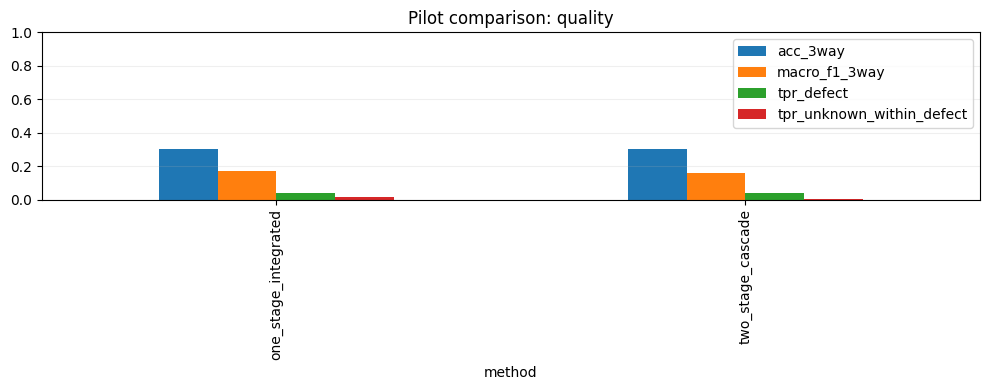

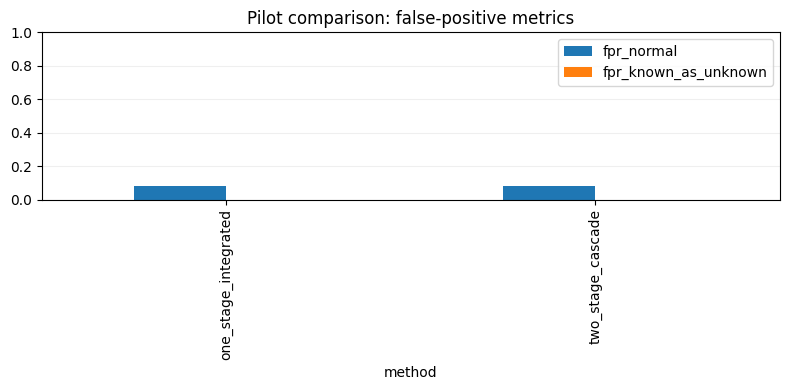

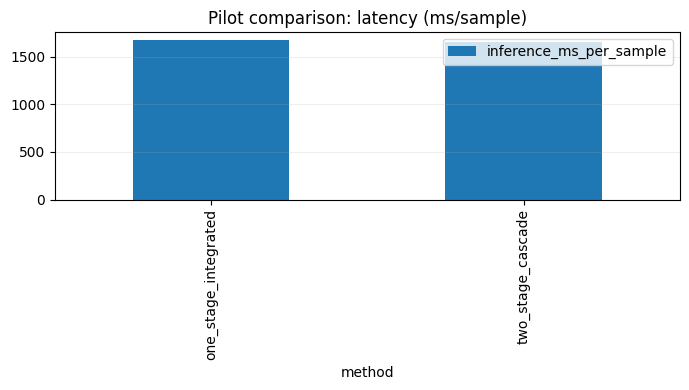

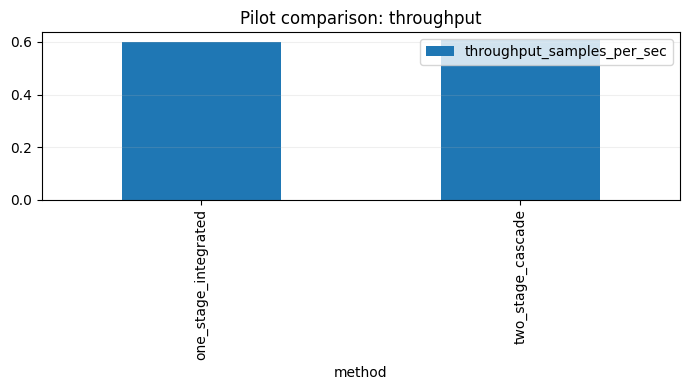

,method,train_total_sec,inference_ms_per_sample,throughput_samples_per_sec
0,one_stage_integrated,6942.534656,1671.277647,0.598345
1,two_stage_cascade,6942.534656,1649.359641,0.606296


In [11]:
# Cell 9: Quick quality + runtime plots
import matplotlib.pyplot as plt

cmp = pd.read_csv(Path(cfg['output_dir']) / 'pilot_compare_results.csv')

ax = cmp.plot(x='method', y=['acc_3way','macro_f1_3way','tpr_defect','tpr_unknown_within_defect'], kind='bar', figsize=(10,4), title='Pilot comparison: quality')
ax.set_ylim(0,1)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

ax = cmp.plot(x='method', y=['fpr_normal','fpr_known_as_unknown'], kind='bar', figsize=(8,4), title='Pilot comparison: false-positive metrics')
ax.set_ylim(0,1)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

ax = cmp.plot(x='method', y=['inference_ms_per_sample'], kind='bar', figsize=(7,4), title='Pilot comparison: latency (ms/sample)')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

ax = cmp.plot(x='method', y=['throughput_samples_per_sec'], kind='bar', figsize=(7,4), title='Pilot comparison: throughput')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

display(cmp[['method','train_total_sec','inference_ms_per_sample','throughput_samples_per_sec']])
